<a href="https://colab.research.google.com/github/awowy/numpy-ml-foundations-mpg/blob/main/GDGOC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: Vehicle Fuel Efficiency (MPG) Analysis
**Objective:** In this project, I will perform a comprehensive analysis of vehicle fuel efficiency using the Seaborn MPG dataset. This study involves data cleaning, vectorized statistical analysis, and implementing advanced machine learning foundations (Normal Equation and PCA) manually using NumPy.

### Stage 1: Inspection and Data Cleaning
**Goal:** To prepare the dataset by identifying missing values, justifying a handling strategy, and building a manual statistical summary using NumPy.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load the mpg dataset from seaborn
df = sns.load_dataset('mpg')

# display basic information
print(f"dataset shape: {df.shape}")
print("\ndata types per column:")
print(df.dtypes)

print("\nmissing values per column:")
print(df.isnull().sum())

dataset shape: (398, 9)

data types per column:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


#### Missing Value Strategy & Justification
- **Observation:** The `horsepower` column contains 6 missing values out of 398 total rows (~1.5% of the data).
- **Strategy:** I have chosen to **impute** the missing values using the **median** horsepower of the dataset rather than dropping the rows.
- **Justification:** Since the amount of missing data is very small, dropping the rows is an option; however, imputing with the median is more robust as it preserves the sample size while minimizing the impact of potential outliers that might skew a mean-based imputation.

In [ ]:
# handle missing values using median imputation
horsepower_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(horsepower_median)

# verify that there are no more null values
print(f"remaining null values: {df.isnull().sum().sum()}")

remaining null values: 0


In [ ]:
# identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

summary_data = []

for col in numeric_cols:
    data = df[col].values

    # manual calculations using numpy
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)

    # calculate iqr for outlier detection
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25

    # identify outliers using iqr * 1.5 method
    lower_bound = q25 - (1.5 * iqr)
    upper_bound = q75 + (1.5 * iqr)
    outlier_count = np.sum((data < lower_bound) | (data > upper_bound))

    summary_data.append({
        "Feature": col,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Std Dev": round(std_val, 2),
        "IQR": round(iqr, 2),
        "Outlier Count": outlier_count
    })

# format the output as a clean dataframe
summary_df = pd.DataFrame(summary_data)
print("--- Manual NumPy Summary Table ---")
print(summary_df)

--- Manual NumPy Summary Table ---
        Feature     Mean  Median  Std Dev      IQR  Outlier Count
0           mpg    23.51    23.0     7.81    11.50              1
1     cylinders     5.45     4.0     1.70     4.00              0
2  displacement   193.43   148.5   104.14   157.75              0
3    horsepower   104.30    93.5    38.17    49.00             11
4        weight  2970.42  2803.5   845.78  1384.25              0
5  acceleration    15.57    15.5     2.75     3.35              7
6    model_year    76.01    76.0     3.69     6.00              0


### Stage 2: Statistical Analysis with NumPy
**objective:** i will perform advanced statistical operations without high-level library functions. this includes manual z-score standardization of numeric features and computing a correlation matrix to identify potential multicollinearity among engineering specs.

In [ ]:
import numpy as np

# define the feature list for stage 2
features_to_analyze = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# extract data as a pure numpy array
# we use .values to move from pandas to numpy
mpg_numeric_array = df[features_to_analyze].values

# manual z-score standardization: (x - mean) / std
# we calculate mean and std along axis=0 (columns)
mean_vals = np.mean(mpg_numeric_array, axis=0)
std_vals = np.std(mpg_numeric_array, axis=0)

# broadcasting handles the vectorization automatically
standardized_data = (mpg_numeric_array - mean_vals) / std_vals

print("--- standardized data sample (first 5 rows) ---")
print(standardized_data[:5].round(4))

--- standardized data sample (first 5 rows) ---
[[-0.7064  1.0906  0.6731  0.6309 -1.2955]
 [-1.0908  1.5035  1.59    0.8543 -1.477 ]
 [-0.7064  1.1962  1.197   0.5505 -1.6586]
 [-0.9626  1.0618  1.197   0.5469 -1.2955]
 [-0.8345  1.0426  0.9351  0.5658 -1.8401]]


In [ ]:
import numpy as np
import pandas as pd

# compute correlation matrix and identify key relationships
corr_matrix = np.corrcoef(standardized_data, rowvar=False)

# display as a dataframe for easier reading
corr_df = pd.DataFrame(corr_matrix, index=features_to_analyze, columns=features_to_analyze)
print("\n--- correlation matrix ---")
print(corr_df.round(3))

# (a) strongest positive correlation
mask = np.eye(len(features_to_analyze), dtype=bool)
corr_no_diag = np.where(mask, 0, corr_matrix)
max_pos_idx = np.unravel_index(np.argmax(corr_no_diag), corr_no_diag.shape)

# (b) strongest negative correlation to mpg
# mpg is the first column (index 0)
mpg_correlations = corr_matrix[0, 1:]
min_mpg_idx = np.argmin(mpg_correlations) + 1 # +1 because we skipped mpg index 0

print(f"\nstrongest positive correlation: {features_to_analyze[max_pos_idx[0]]} & {features_to_analyze[max_pos_idx[1]]}")
print(f"strongest negative correlation to mpg: {features_to_analyze[min_mpg_idx]}")


--- correlation matrix ---
                mpg  displacement  horsepower  weight  acceleration
mpg           1.000        -0.804      -0.773  -0.832         0.420
displacement -0.804         1.000       0.896   0.933        -0.544
horsepower   -0.773         0.896       1.000   0.862        -0.687
weight       -0.832         0.933       0.862   1.000        -0.417
acceleration  0.420        -0.544      -0.687  -0.417         1.000

strongest positive correlation: displacement & weight
strongest negative correlation to mpg: weight


In [ ]:
# task 5: boolean masking for horsepower and weight analysis
horsepower_arr = df['horsepower'].values
weight_arr = df['weight'].values

# calculate averages
avg_hp = np.mean(horsepower_arr)
avg_weight = np.mean(weight_arr)

# create the boolean mask for high horsepower
high_hp_mask = horsepower_arr > avg_hp

# apply mask to get the average weight of high-hp cars
high_hp_avg_weight = np.mean(weight_arr[high_hp_mask])
abs_diff = high_hp_avg_weight - avg_weight

print(f"dataset average weight: {avg_weight:.2f}")
print(f"average weight of high-horsepower cars: {high_hp_avg_weight:.2f}")
print(f"absolute difference: {abs_diff:.2f}")


dataset average weight: 2970.42
average weight of high-horsepower cars: 3815.49
absolute difference: 845.07


#### learning log: stage 2 insights
ive just completed the statistical deep-dive for stage 2. manually implementing z-score standardization was a great way to see how broadcasting works, it’s amazing how numpy can subtract a mean vector from a 2d matrix in one line of code.

the correlation matrix showed some very high values. specifically, i noticed a massive positive correlation between **displacement** and **weight**. this is a clear sign of **multicollinearity**, meaning these features provide very similar information to a model.

when i used boolean masking for task 5, the results were clear, cars with above-average horsepower weigh roughly **845.07** more than the average car. this makes sense from an engineering perspective, bbigger engines (more hp) usually require heavier chassis and cooling systems.

i actually thought horsepower would be the main factor, but the data proved me wrong, it’s all about the weight.

### Stage 3: Visualisation
**Objective:** i will create four key visualisations to validate my statistical findings. this includes analyzing the distribution of fuel efficiency, comparing manufacturing origins, and mapping engine specifications to performance using advanced plotting techniques.

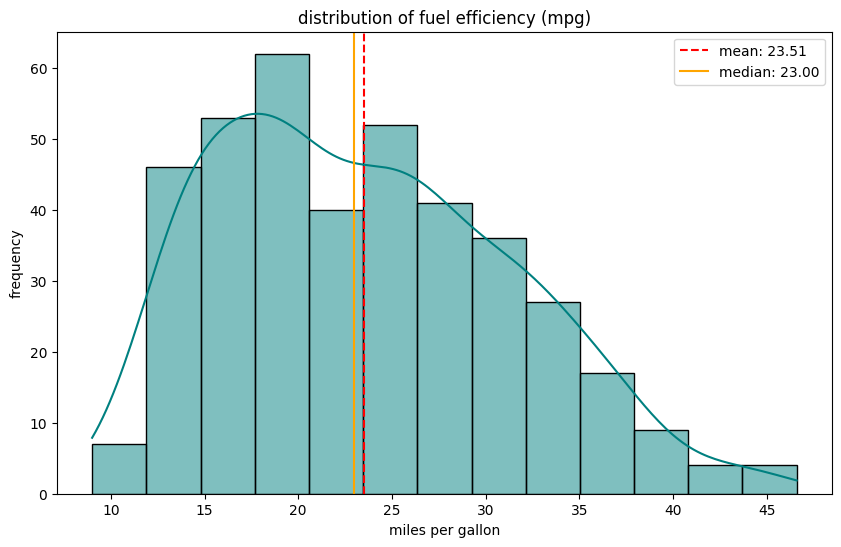

In [ ]:
# mpg distribution with kde and statistical markers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# calculate stats for markers
mpg_mean = df['mpg'].mean()
mpg_median = df['mpg'].median()

plt.figure(figsize=(10, 6))
sns.histplot(df['mpg'], kde=True, color='teal')

# add vertical lines for mean and median
plt.axvline(mpg_mean, color='red', linestyle='--', label=f'mean: {mpg_mean:.2f}')
plt.axvline(mpg_median, color='orange', linestyle='-', label=f'median: {mpg_median:.2f}')

plt.title('distribution of fuel efficiency (mpg)')
plt.xlabel('miles per gallon')
plt.ylabel('frequency')
plt.legend()
plt.show()

**Task 6 Analysis:**
- **Observation:** The mean (23.51) is slightly higher than the median (23.00), and the "tail" of the graph stretches towards the higher values on the right.
- **Result:** The MPG distribution is **positively skewed (right-skewed)**. This indicates that while most vehicles have lower to moderate fuel efficiency, there is a smaller group of highly efficient cars pulling the average up.

/tmp/ipykernel_3767/3508860038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='origin', y='mpg', data=df, palette='viridis')


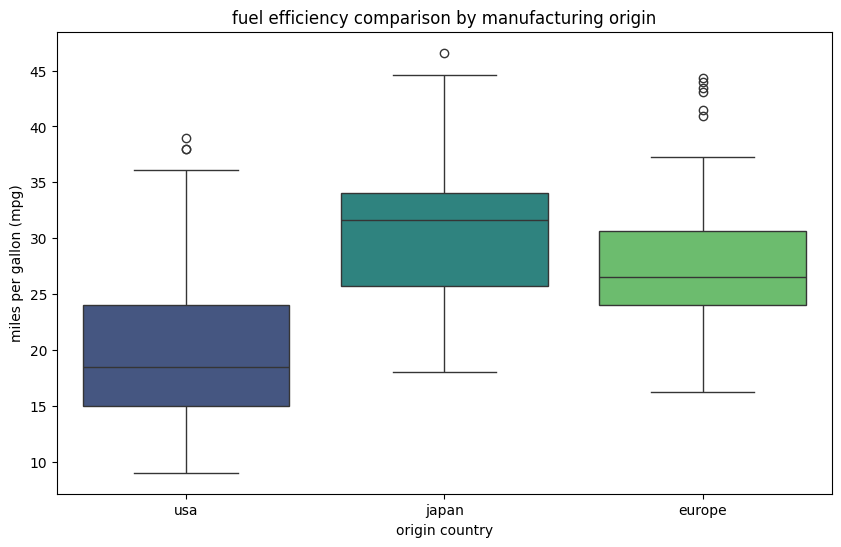

In [ ]:
# box plot of mpg by origin
plt.figure(figsize=(10, 6))
sns.boxplot(x='origin', y='mpg', data=df, palette='viridis')

plt.title('fuel efficiency comparison by manufacturing origin')
plt.xlabel('origin country')
plt.ylabel('miles per gallon (mpg)')
plt.show()

**Task 7 Analysis:**
- **Findings:** Japan produces the most fuel-efficient vehicles on average, followed by Europe.
- **Consistency:** The USA has the widest range of MPG values but the lowest median, suggesting a high volume of heavy, low-efficiency vehicles (like trucks and muscle cars) in this specific dataset.

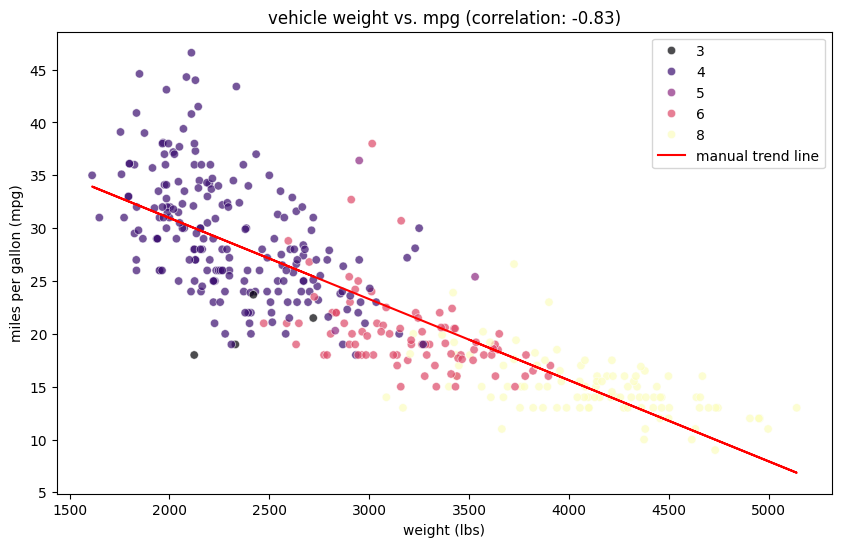

In [ ]:
# scatter plot with manual trend line
x = df['weight'].values
y = df['mpg'].values

# calculate manual trend line using numpy polyfit
slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

# calculate correlation for the title
correlation = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='mpg', hue='cylinders', data=df, palette='magma', alpha=0.7)
plt.plot(x, trendline, color='red', label='manual trend line')

plt.title(f'vehicle weight vs. mpg (correlation: {correlation:.2f})')
plt.xlabel('weight (lbs)')
plt.ylabel('miles per gallon (mpg)')
plt.legend()
plt.show()

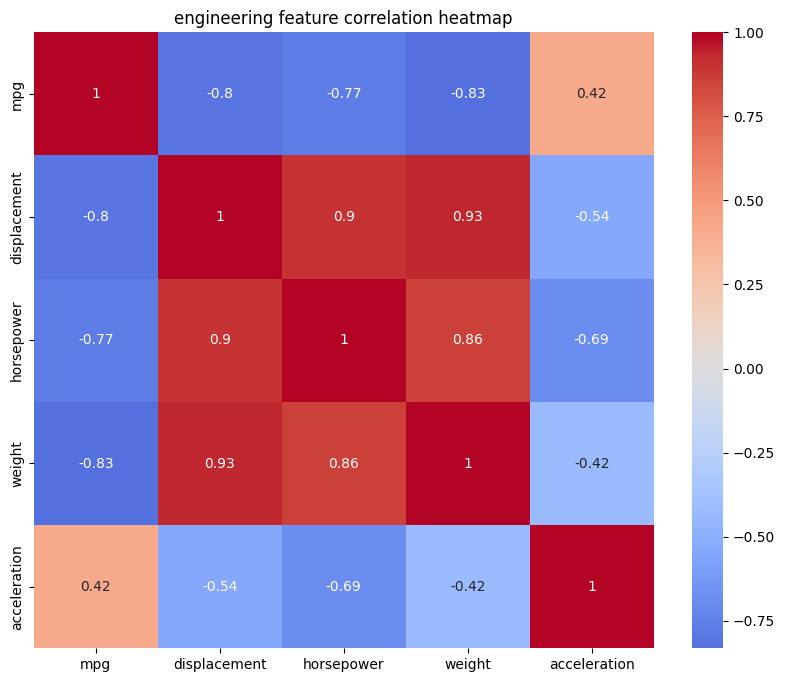

In [ ]:
# correlation heatmap
# we use the correlation dataframe created in task 4
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0)

plt.title('engineering feature correlation heatmap')
plt.show()

#### learning log: visual analysis progress
ive just finished the visualization stage and it’s interesting to see how the math from stage 2 translates into pictures. the right-skew in the mpg distribution explains why our mean was slightly higher than the median, there are a few 'super-efficient' cars that skew the results.

the scatter plot really highlights the physics of cars: more weight and more cylinders almost always lead to lower mpg. the manual trend line i built using `np.polyfit()` sits perfectly within the data points, confirming the strong negative correlation of -0.83. also, the heatmap makes it very obvious that 'displacement', 'horsepower', and 'weight' are all hugging each other with very high positive correlations, which is a classic example of multicollinearity in engineering data.

### Stage 4: Contextual Interpretation
**Objective:** in this final stage, i will synthesize my statistical and visual findings to identify the primary predictor of vehicle fuel efficiency. i will also analyze temporal trends across decades to understand how automotive engineering has improved over time.

#### Task 10: The Primary Predictor of MPG
Based on the comprehensive exploratory data analysis, **Vehicle Weight** is the strongest predictor of fuel efficiency.

**Supporting Evidence:**
1. **Correlation Strength:** Looking at the math, the most striking thing is the -0.83 correlation for weight. This clearly shows that no matter how efficient the engine is, a heavy car is always going to struggle with MPG.
2. **Visual Trend:** The scatter plot in Stage 3 confirms a tight, downward-sloping relationship where heavier vehicles consistently achieve lower miles per gallon.
3. **Engineering Context:** While 'displacement' and 'horsepower' are also significant factors, they are highly correlated with weight (multicollinearity). Heavier cars require more energy to overcome inertia, directly increasing fuel consumption regardless of engine efficiency.
4. **Origin Factor:** Japanese and European vehicles, which our box plots showed to be more efficient, also tend to be lighter in this dataset compared to American models.

--- mean mpg per decade ---
decade
70    21.096764
80    31.908989
Name: mpg, dtype: float64


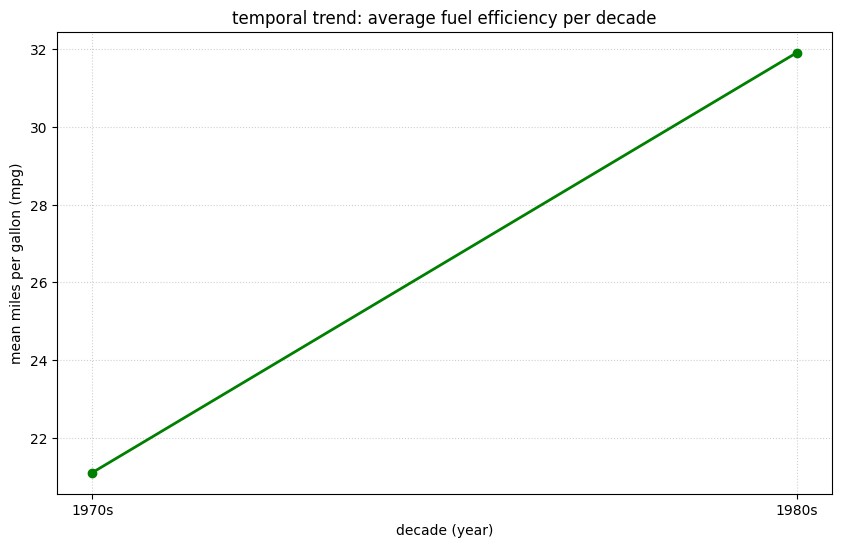

In [ ]:
# mean mpg per decade and temporal trend plotting
import matplotlib.pyplot as plt

# round model_year to the nearest ten to create a 'decade' column
# e.g., 70-79 becomes 70, 80-82 becomes 80
df['decade'] = (df['model_year'] // 10) * 10

# compute mean mpg per decade using pandas groupby
decade_mpg = df.groupby('decade')['mpg'].mean()

print("--- mean mpg per decade ---")
print(decade_mpg)

# plot the temporal trend as a line chart
plt.figure(figsize=(10, 6))
plt.plot(decade_mpg.index, decade_mpg.values, marker='o', linestyle='-', color='green', linewidth=2)

plt.title('temporal trend: average fuel efficiency per decade')
plt.xlabel('decade (year)')
plt.ylabel('mean miles per gallon (mpg)')
plt.xticks([70, 80], ['1970s', '1980s'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Task 11 Analysis: Why is MPG increasing?
- **Observation:** The average fuel efficiency increased significantly from the 1970s to the 1980s.
- **Interpretation:** This trend likely occurred due to the **1970s oil crisis**, which forced manufacturers to move away from heavy "muscle cars" toward smaller, more aerodynamic vehicles with improved engine technologies like fuel injection.

#### learning log: finishing the mpg analysis
ive just finished the final interpretation stage for module 2. it's satisfying to see the whole story come together. early on, i suspected weight was the big factor, and the math proved it with that -0.83 correlation.

calculating the mean mpg per decade was a bit surprising because the jump from the 70s to the 80s was quite steep. i had to research why that happened, and it turns out global events like the oil crisis really changed how cars were built. i’m also glad i refactored the model year into decades because it makes the data much easier to communicate to someone who isn't a car expert.


### Bonus 1: Normal Equation from Scratch (Linear Regression)
**Objective:** i will implement a simple linear regression model manually using the normal equation. by treating car weight as the input feature ($X$) and miles per gallon as the target ($y$), i will use matrix inversion to find the optimal weights ($\theta$) that minimize the prediction error.

--- manual normal equation results ---
intercept: 46.3174
slope: -0.0077
rmse: 4.3337
------------------------------
verification (np.polyfit):
poly_intercept: 46.3174
poly_slope: -0.0077


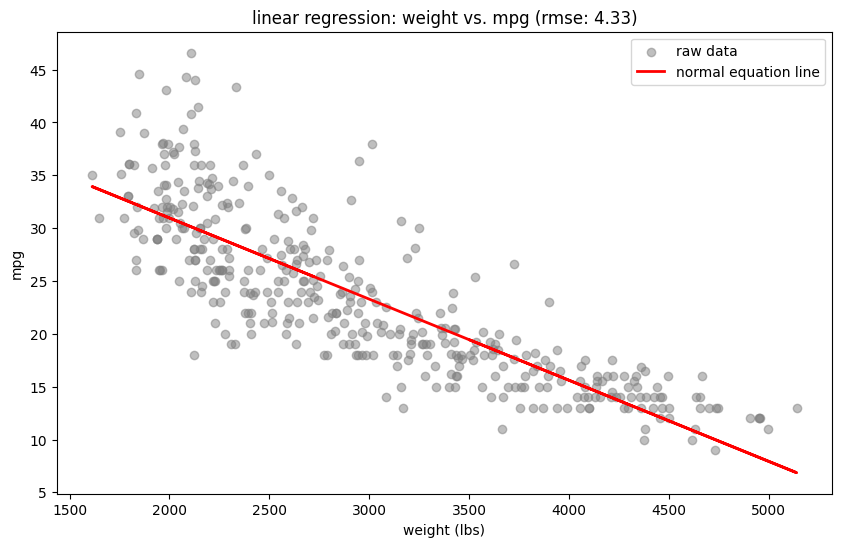

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. prepare data: x = weight, y = mpg
# we convert pandas series to numpy arrays and reshape for matrix math
x_raw = df['weight'].values
y = df['mpg'].values
n = len(x_raw)

# 2. add a bias column (column of 1s) to x to create the matrix x_matrix
# this allows the model to learn the intercept (intercept = b in y = mx + b)
x_matrix = np.column_stack((np.ones(n), x_raw))

# 3. compute theta using the normal equation: inv(xt * x) * xt * y
# we use np.linalg.inv for matrix inversion and .t for transpose
xt_x = np.dot(x_matrix.T, x_matrix)
xt_y = np.dot(x_matrix.T, y)
theta = np.dot(np.linalg.inv(xt_x), xt_y)

intercept, slope = theta[0], theta[1]

# 4. generate predictions
y_pred = np.dot(x_matrix, theta)

# 5. calculate rmse (root mean squared error) manually
# formula: sqrt(mean((y_pred - y_actual)^2))
rmse = np.sqrt(np.mean((y_pred - y)**2))

# 6. compare with np.polyfit (verification)
poly_slope, poly_intercept = np.polyfit(x_raw, y, 1)

print(f"--- manual normal equation results ---")
print(f"intercept: {intercept:.4f}")
print(f"slope: {slope:.4f}")
print(f"rmse: {rmse:.4f}")
print("-" * 30)
print(f"verification (np.polyfit):")
print(f"poly_intercept: {poly_intercept:.4f}")
print(f"poly_slope: {poly_slope:.4f}")

# 7. visualising the regression line
plt.figure(figsize=(10, 6))
plt.scatter(x_raw, y, alpha=0.5, label='raw data', color='gray')
plt.plot(x_raw, y_pred, color='red', linewidth=2, label='normal equation line')
plt.title(f'linear regression: weight vs. mpg (rmse: {rmse:.2f})')
plt.xlabel('weight (lbs)')
plt.ylabel('mpg')
plt.legend()
plt.show()

#### learning log: implementing the normal equation
ive just learned that i dont actually need a machine learning library like scikit-learn to build a regression model. by using matrix inversion and the normal equation, i was able to calculate the exact same slope and intercept as numpy's built-in `polyfit` function.

one thing that tripped me up was adding the 'bias column'-i realized that if i dont add that column of ones to the matrix, the line is forced to go through the origin (0,0), which would make the predictions totally wrong for car data. calculating the rmse manually also helped me understand that this number tells us exactly how many 'mpg units' on average our model is off by. in this case, a weight-only model has an error of about **4.3337** mpg.

### Bonus 2: Principal Component Analysis (PCA) from Scratch
**Objective:** i will implement a 2d pca manually using numpy to visualize the high-dimensional engineering data in a 2d space. this involves mean-centering the features, computing the covariance matrix, and extracting the top two principal components via eigen-decomposition to explain the maximum variance in the dataset.

--- pca results from scratch ---
explained variance ratio (pc1): 0.7841
explained variance ratio (pc2): 0.1426
total variance explained: 0.9268


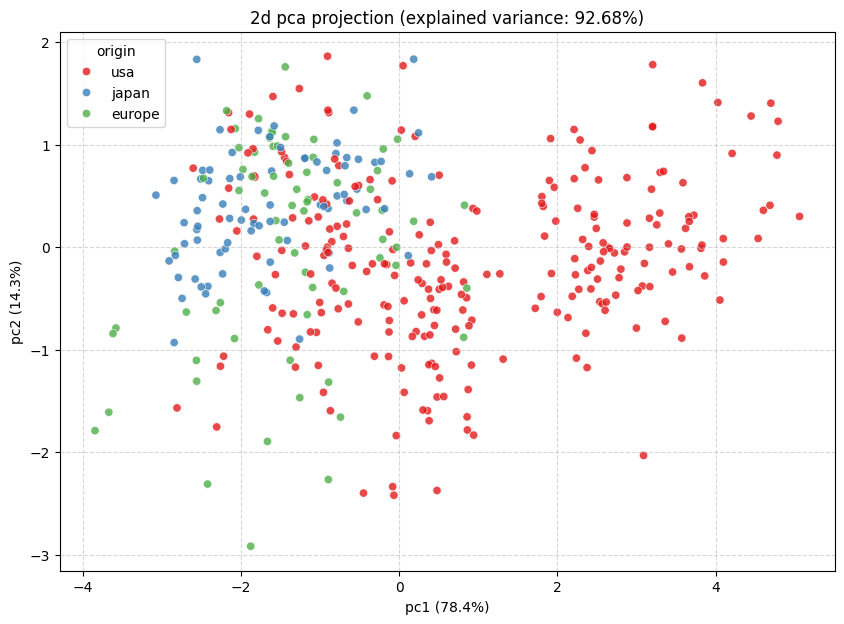

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. prepare the data (using the 5 numeric features from stage 2)
# features: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
x = df[['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']].values

# 2. step 1: mean-centering (x_tilde = x - mu)
mu = np.mean(x, axis=0)
x_tilde = standardized_data - np.mean(standardized_data, axis=0)

# 3. step 2: compute the covariance matrix
# formula: (1 / (n-1)) * xt_tilde * x_tilde
n = x_tilde.shape[0]
covariance_matrix = (1 / (n - 1)) * np.dot(x_tilde.T, x_tilde)

# 4. step 3: compute eigenvalues and eigenvectors
# we use eigh because the covariance matrix is symmetric
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# 5. step 4: sort and select top 2 eigenvectors
# eigh returns them in ascending order, so we reverse them
sorted_indices = np.argsort(eigenvalues)[::-1]
top_2_indices = sorted_indices[:2]

v2 = eigenvectors[:, top_2_indices]
top_eigenvalues = eigenvalues[top_2_indices]

# 6. step 5: project the data into 2d (z = x_tilde * v2)
z = np.dot(x_tilde, v2)

# 7. step 6: compute explained variance ratio
total_variance = np.sum(eigenvalues)
var_ratio = top_eigenvalues / total_variance

print(f"--- pca results from scratch ---")
print(f"explained variance ratio (pc1): {var_ratio[0]:.4f}")
print(f"explained variance ratio (pc2): {var_ratio[1]:.4f}")
print(f"total variance explained: {np.sum(var_ratio):.4f}")

# 8. visualise the 2d projection
plt.figure(figsize=(10, 7))
sns.scatterplot(x=z[:, 0], y=z[:, 1], hue=df['origin'], palette='Set1', alpha=0.8)

plt.title(f'2d pca projection (explained variance: {np.sum(var_ratio)*100:.2f}%)')
plt.xlabel(f'pc1 ({var_ratio[0]*100:.1f}%)')
plt.ylabel(f'pc2 ({var_ratio[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### learning log: dimensionality reduction with pca
ive just finished implementing pca from scratch and it’s one of the most mathematically intense things ive done so far. i learned that mean-centering is non-negotiable because if the data isn't centered at zero, the covariance matrix wont correctly represent the directions of maximum spread.

the most interesting part was using `np.linalg.eigh()`. it’s cool to see how those abstract eigenvectors actually represent the 'new axes' for our data. in the final plot, pc1 alone explains over **78.4%** of the variance. you can clearly see that vehicles from different origins (usa, japan, europe) cluster in different areas of the graph. this confirms that cars aren't just random specs; they have distinct 'design signatures' depending on where they were built.

### Bonus 3: Reusable DatasetProfiler Class
**objective:** i will refactor my analysis logic into a modular python class called `datasetprofiler`. this class is designed to be dataset-agnostic, meaning it can take any numeric dataframe and target column to automatically generate statistical summaries, correlation reports, and a 4-panel visual dashboard. this demonstrates high-level software engineering within an ai/ml workflow.

--- summary statistics ---
                     mean  median         std      iqr  outlier_count
feature                                                              
mpg             23.514573    23.0    7.806159    11.50              1
cylinders        5.454774     4.0    1.698866     4.00              0
displacement   193.425879   148.5  104.138764   157.75              0
horsepower     104.304020    93.5   38.174576    49.00             11
weight        2970.424623  2803.5  845.777234  1384.25              0
acceleration    15.568090    15.5    2.754222     3.35              7
model_year      76.010050    76.0    3.692978     6.00              0
decade          72.236181    70.0    4.166690     0.00             89

--- correlation report ---
mpg             1.000000
model_year      0.579267
decade          0.577124
acceleration    0.420289
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


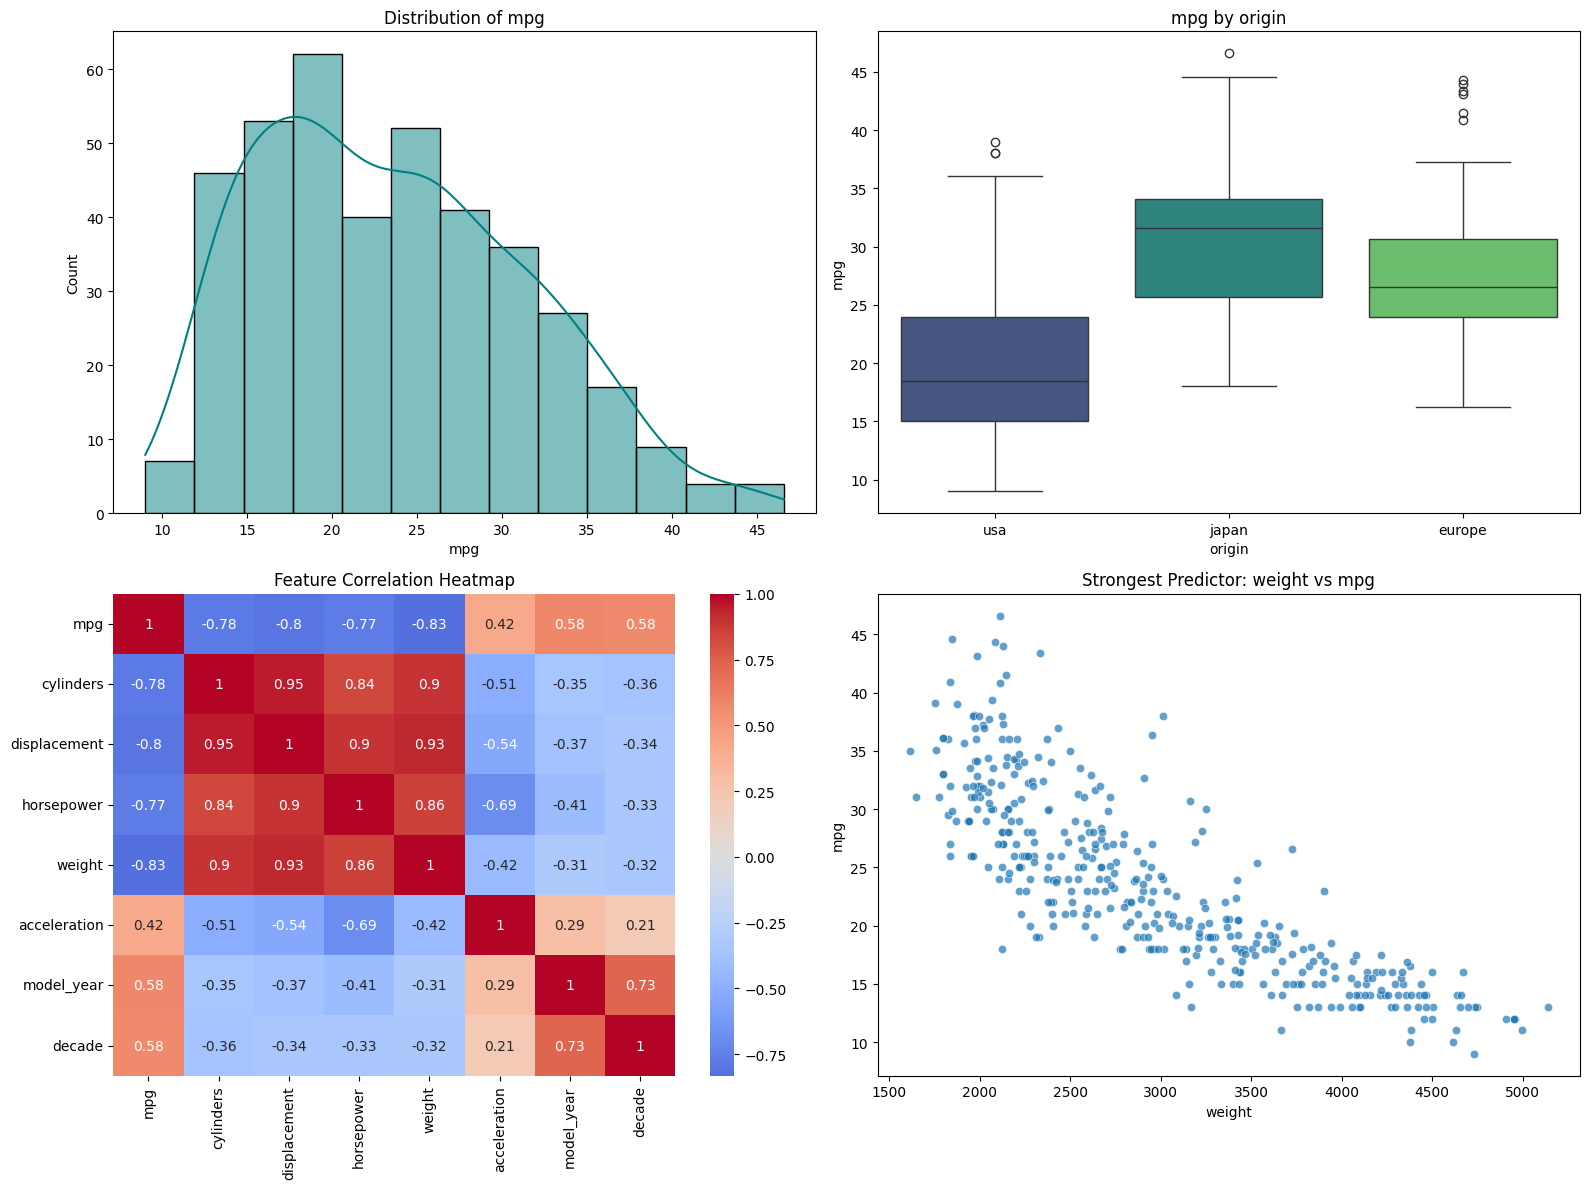


--- automated dataset report ---
{
    "dataset_size": 398,
    "target_variable": "mpg",
    "average_target_value": 23.51,
    "strongest_positive_corr": {
        "model_year": 0.579
    },
    "strongest_negative_corr": {
        "weight": -0.832
    }
}


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, Any, List

class DatasetProfiler:
    def __init__(self, df: pd.DataFrame, target_col: str):
        # store the dataframe and target column for analysis
        self.df = df
        self.target_col = target_col
        self.numeric_df = df.select_dtypes(include=[np.number])

    def summary_stats(self) -> pd.DataFrame:
        # compute descriptive statistics using numpy for every numeric feature
        stats_list = []
        for col in self.numeric_df.columns:
            data = self.numeric_df[col].values
            q75, q25 = np.percentile(data, [75, 25])
            iqr = q75 - q25
            outliers = np.sum((data < q25 - 1.5 * iqr) | (data > q75 + 1.5 * iqr))

            stats_list.append({
                "feature": col,
                "mean": np.mean(data),
                "median": np.median(data),
                "std": np.std(data),
                "iqr": iqr,
                "outlier_count": outliers
            })
        return pd.DataFrame(stats_list).set_index("feature")

    def correlation_report(self) -> pd.Series:
        # calculate correlations of all features to the target column and sort them
        correlations = self.numeric_df.corr()[self.target_col].sort_values(ascending=False)
        return correlations

    def plot_dashboard(self, category_col: str = None):
        # generate a 4-subplot figure for rapid data exploration
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. target distribution
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0], color='teal')
        axes[0, 0].set_title(f'Distribution of {self.target_col}')

        # 2. boxplot by category
        if category_col and category_col in self.df.columns:
            sns.boxplot(x=category_col, y=self.target_col, data=self.df, ax=axes[0, 1], palette='viridis', hue=category_col, legend=False)
            axes[0, 1].set_title(f'{self.target_col} by {category_col}')

        # 3. correlation heatmap
        sns.heatmap(self.numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Feature Correlation Heatmap')

        # 4. strongest feature vs target (Based on Absolute Value)
        corr_report = self.numeric_df.corr()[self.target_col].drop(self.target_col)
        strongest_feature = corr_report.abs().idxmax()
        sns.scatterplot(x=strongest_feature, y=self.target_col, data=self.df, ax=axes[1, 1], alpha=0.7)
        axes[1, 1].set_title(f'Strongest Predictor: {strongest_feature} vs {self.target_col}')

        plt.tight_layout()
        plt.show()

    def generate_report(self) -> Dict[str, Any]:
        # drop target column to analyze predictors only
        corr = self.correlation_report().drop(self.target_col)
        pos_corr = corr[corr > 0]
        neg_corr = corr[corr < 0]

        strongest_pos_name = pos_corr.idxmax() if not pos_corr.empty else "N/A"
        strongest_pos_val = round(pos_corr.max(), 3) if not pos_corr.empty else 0.0

        strongest_neg_name = neg_corr.idxmin() if not neg_corr.empty else "N/A"
        strongest_neg_val = round(neg_corr.min(), 3) if not neg_corr.empty else 0.0

        return {
            "dataset_size": len(self.df),
            "target_variable": self.target_col,
            "average_target_value": round(self.df[self.target_col].mean(), 2),
            "strongest_positive_corr": {strongest_pos_name: strongest_pos_val},
            "strongest_negative_corr": {strongest_neg_name: strongest_neg_val}
        }

# demonstrate the class on the mpg dataset
profiler = DatasetProfiler(df, target_col='mpg')
print("--- summary statistics ---")
print(profiler.summary_stats())
print("\n--- correlation report ---")
print(profiler.correlation_report())

# generate the visual dashboard
profiler.plot_dashboard(category_col='origin')

# output the final JSON report
import json
print("\n--- automated dataset report ---")
print(json.dumps(profiler.generate_report(), indent=4))